# EDA

This first part focuses on data exploration and manipulation.

In [55]:
import numpy as np
import matplotlib.pyplot as plt
import pandas as pd
import matchms
import pickle

In [56]:
# filename = "ALL_GNPS_20200511.json"
# spectra = matchms.load_from_json(f"src/data/{filename}")

# list_spectra = list(spectra)
# print(f"Number of spectra: {len(list_spectra)}")

# with open("src/data/gnps_spectra.pkl", "wb") as f:
#     pickle.dump(list_spectra, f)

In [57]:
with open("src/data/gnps_spectra.pkl", "rb") as f:
    spectra = pickle.load(f)

In [58]:
type(spectra[0])

matchms.Spectrum.Spectrum

In [59]:
for spectrum in spectra[:5]:
  print(f"m/z range: {spectrum.peaks.mz.min()} - {spectrum.peaks.mz.max()}")

m/z range: 289.286377 - 982.221924
m/z range: 278.049927 - 940.88324
m/z range: 128.838745 - 455.885986
m/z range: 343.896484 - 546.972168
m/z range: 101.015465 - 1097.665161


### Different molecules have different m/z range

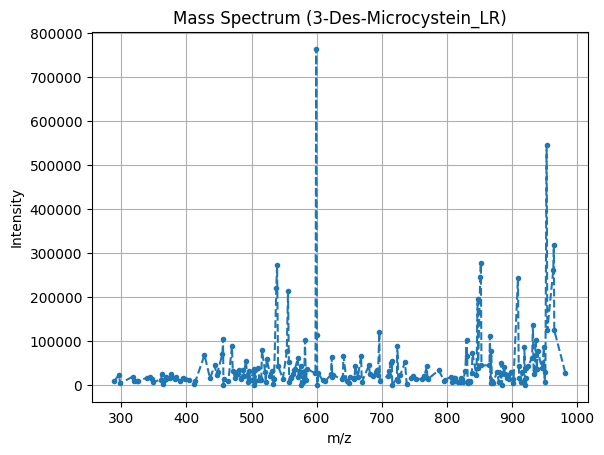

In [60]:
plt.plot(spectra[0].peaks.mz, spectra[0].peaks.intensities, '--.')
plt.xlabel("m/z")
plt.ylabel("Intensity")
plt.title(f"Mass Spectrum ({spectra[0].metadata.get('compound_name', 'Unknown')})")
plt.grid()
plt.show()

### To compute spectral similarity, normalization is needed

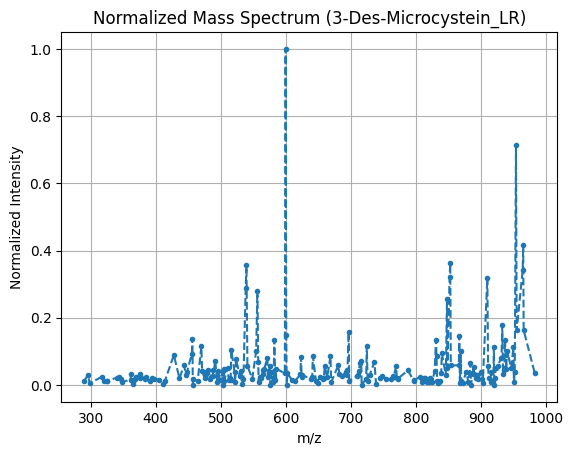

In [61]:
# normalize intensities to [0, 1]
normalized_intensities = spectra[0].peaks.intensities / np.max(spectra[0].peaks.intensities)
plt.plot(spectra[0].peaks.mz, normalized_intensities, '--.')
plt.xlabel("m/z")
plt.ylabel("Normalized Intensity")
plt.title(f"Normalized Mass Spectrum ({spectra[0].metadata.get('compound_name', 'Unknown')})")
plt.grid()
plt.show()

### Now we can try to visually compare intensities

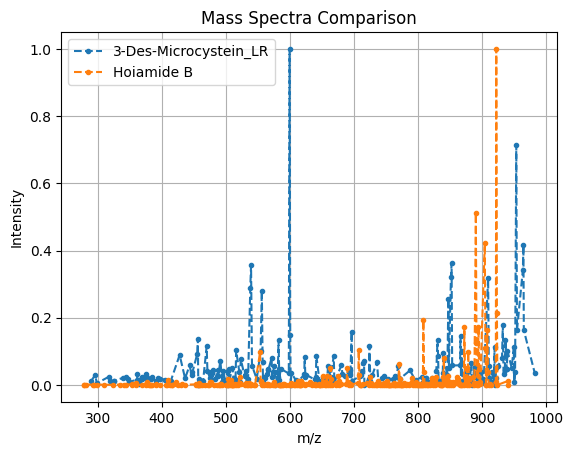

In [62]:
normalized1 = spectra[0].peaks.intensities / np.max(spectra[0].peaks.intensities)
normalized2 = spectra[1].peaks.intensities / np.max(spectra[1].peaks.intensities)
plt.plot(spectra[0].peaks.mz, normalized1, '--.', label=f"{spectra[0].metadata.get('compound_name', 'Unknown')}")
plt.plot(spectra[1].peaks.mz, normalized2, '--.', label=f"{spectra[1].metadata.get('compound_name', 'Unknown')}")
plt.xlabel("m/z")
plt.ylabel("Intensity")
plt.title("Mass Spectra Comparison")
plt.legend()
plt.grid()
plt.show()

In [63]:
# # check if sum of normalized intensities is 1
# print(f"Sum of normalized intensities (spectrum 1): {np.sum(normalized1)}")
# print(f"Sum of normalized intensities (spectrum 2): {np.sum(normalized2)}")

### Preprocessing

In [64]:
import matchms.filtering as ms_filters

def metadata_processing(spectrum):
    spectrum = ms_filters.default_filters(spectrum)
    # spectrum = ms_filters.repair_inchi_inchikey_smiles(spectrum)
    # spectrum = ms_filters.derive_inchi_from_smiles(spectrum)
    # spectrum = ms_filters.derive_smiles_from_inchi(spectrum)
    # spectrum = ms_filters.derive_inchikey_from_inchi(spectrum)
    spectrum = ms_filters.harmonize_undefined_smiles(spectrum)
    spectrum = ms_filters.harmonize_undefined_inchi(spectrum)
    spectrum = ms_filters.harmonize_undefined_inchikey(spectrum)
    spectrum = ms_filters.add_precursor_mz(spectrum)
    return spectrum

def peak_processing(spectrum):
    spectrum = ms_filters.default_filters(spectrum)
    spectrum = ms_filters.normalize_intensities(spectrum)
    spectrum = ms_filters.select_by_intensity(spectrum, intensity_from=0.01)
    spectrum = ms_filters.select_by_mz(spectrum, mz_from=10, mz_to=1000)
    return spectrum

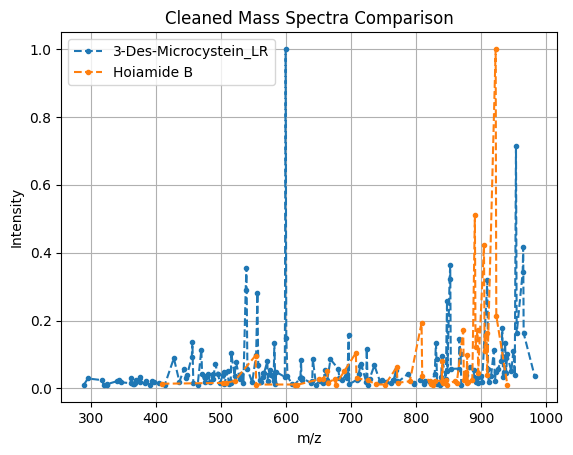

In [65]:
clean1 = metadata_processing(spectra[0])
clean2 = metadata_processing(spectra[1])

clean1 = peak_processing(spectra[0])
clean2 = peak_processing(spectra[1])

normalized1 = clean1.peaks.intensities / np.max(clean1.peaks.intensities)
normalized2 = clean2.peaks.intensities / np.max(clean2.peaks.intensities)

plt.plot(clean1.peaks.mz, normalized1, '--.', label=f"{spectra[0].metadata.get('compound_name', 'Unknown')}")
plt.plot(clean2.peaks.mz, normalized2, '--.', label=f"{spectra[1].metadata.get('compound_name', 'Unknown')}")
plt.xlabel("m/z")
plt.ylabel("Intensity")
plt.title("Cleaned Mass Spectra Comparison")
plt.legend()
plt.grid()
plt.show()

In [66]:
print(f"{len(spectra[0].peaks.mz)} -> {len(clean1.peaks.mz)}")
print(f"{len(spectra[0].peaks.intensities)} -> {len(clean1.peaks.intensities)}")

218 -> 186
218 -> 186


### Cosine similarity

In [67]:
# compute cosine similarity between the two spectra

from matchms import calculate_scores
from matchms.similarity import CosineGreedy
similarity_measure = CosineGreedy(tolerance=0.005)

spectrums = [spectra[0], spectra[1]]

scores = calculate_scores(spectrums, spectrums, similarity_measure, is_symmetric=True)

Calculating similarities: 100%|██████████████████████████████████████████████| 2/2 [00:00<00:00, 474.42it/s]


In [68]:
scores.score_names

('CosineGreedy_score', 'CosineGreedy_matches')

In [69]:
scores.scores['CosineGreedy_score']

(array([0, 0, 1, 1]),
 array([0, 1, 0, 1]),
 array([1.00000000e+00, 3.47802614e-06, 3.47802614e-06, 1.00000000e+00]))

In [70]:
row, col, val = scores.scores['CosineGreedy_score']

n = len(spectrums)
S = np.zeros((n, n))

S[row, col] = val

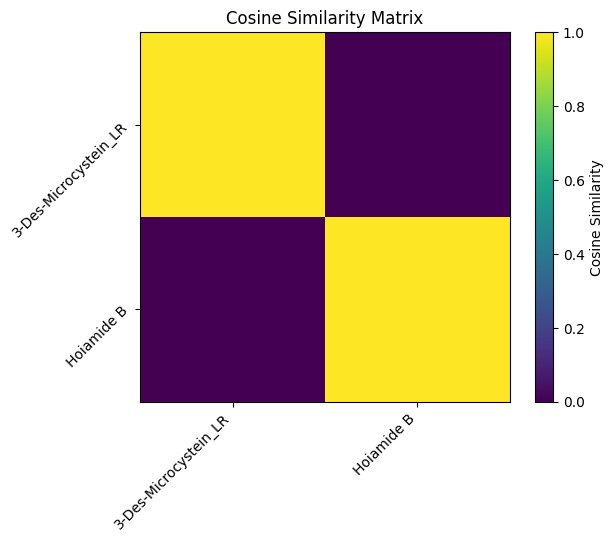

In [129]:
plt.imshow(S, cmap='viridis', vmin=0, vmax=1)
plt.title("Cosine Similarity Matrix")
plt.xticks(ticks=np.arange(n), labels=[s.metadata.get('compound_name', 'Unknown') for s in spectrums], rotation=45, ha='right')
plt.yticks(ticks=np.arange(n), labels=[s.metadata.get('compound_name', 'Unknown') for s in spectrums], rotation=45, ha='right')
plt.colorbar(label='Cosine Similarity')
plt.show()

### Spec2Vec

1. Data preparation (cleaning and subsampling)
2. Convert spectra into documents ("peak@xxx")
3. Convert words into vectors = Train word2vec with CBOW
4. Build spectrum vectors, normalize and compute similarities

In [76]:
import random

samples = random.sample(spectra, 10000)

In [95]:
import logging
logging.getLogger("matchms").setLevel(logging.ERROR)

cleaned_samples = []
for spec in samples:
  clean = metadata_processing(spec)
  clean = peak_processing(clean)
  cleaned_samples.append(clean)

In [ ]:
## manual implementation for tokenization of spectra for Word2Vec training

# sentences = []
# for spec in cleaned_samples:
#     tokens = []
#     for mz in spec.mz:
#         token = f"peak@{round(mz,2)}"
#         tokens.append(token)
#     sentences.append(tokens)

# print(sentences[0])

## output: ['peak@81.02', 'peak@136.07', 'peak@192.1', 'peak@194.08', 'peak@207.1', 'peak@221.11', 'peak@334.16', 'peak@346.2', 'peak@392.2', 'peak@446.25', 'peak@546.3', 'peak@576.31']

In [97]:
def is_valid_spectrum(spec, min_peaks=5):
    try:
        return len(spec.peaks.mz) >= min_peaks
    except:
        return False

valid_samples = [s for s in cleaned_samples if is_valid_spectrum(s)]

In [101]:
len(valid_samples)

7467

In [99]:
from spec2vec import SpectrumDocument

sentences = [SpectrumDocument(s, n_decimals=2) for s in valid_samples]

In [ ]:
print(sentences[0].words)

['peak@81.02', 'peak@136.07', 'peak@192.10', 'peak@194.08', 'peak@207.10', 'peak@221.11', 'peak@334.16', 'peak@346.20', 'peak@392.20', 'peak@446.25', 'peak@546.30', 'peak@576.31']


In [ ]:
# training

from spec2vec.model_building import train_new_word2vec_model

model_file = "src/data/models/intro.model"
model = train_new_word2vec_model(sentences, iterations=[20], filename=model_file,
                                 workers=2, progress_logger=True)

  Epoch 1 of 20.Change in loss after epoch 1: 1136653.75
  Epoch 2 of 20.Change in loss after epoch 2: 868680.125
  Epoch 3 of 20.Change in loss after epoch 3: 695140.125
  Epoch 4 of 20.Change in loss after epoch 4: 593121.5
  Epoch 5 of 20.Change in loss after epoch 5: 602096.25
  Epoch 6 of 20.Change in loss after epoch 6: 466020.75
  Epoch 7 of 20.Change in loss after epoch 7: 478575.5
  Epoch 8 of 20.Change in loss after epoch 8: 415131.5
  Epoch 9 of 20.Change in loss after epoch 9: 377224.5
  Epoch 10 of 20.Change in loss after epoch 10: 357795.5
  Epoch 11 of 20.Change in loss after epoch 11: 422385.5
  Epoch 12 of 20.Change in loss after epoch 12: 285659.0
  Epoch 13 of 20.Change in loss after epoch 13: 323697.5
  Epoch 14 of 20.Change in loss after epoch 14: 302234.0
  Epoch 15 of 20.Change in loss after epoch 15: 316227.5
  Epoch 16 of 20.Change in loss after epoch 16: 293351.5
  Epoch 17 of 20.Change in loss after epoch 17: 266445.0
  Epoch 18 of 20.Change in loss after epo

In [115]:
model.wv.key_to_index.keys()

dict_keys(['peak@95.09', 'peak@91.05', 'peak@109.10', 'peak@105.07', 'peak@93.07', 'peak@107.09', 'peak@121.10', 'peak@81.07', 'peak@119.09', 'peak@133.10', 'peak@95.05', 'peak@79.05', 'peak@135.12', 'peak@123.12', 'peak@131.09', 'peak@145.10', 'peak@57.07', 'peak@117.07', 'peak@147.12', 'peak@85.03', 'peak@97.10', 'peak@107.05', 'peak@67.05', 'peak@69.07', 'peak@83.05', 'peak@69.03', 'peak@159.12', 'peak@129.07', 'peak@149.13', 'peak@61.01', 'peak@79.02', 'peak@135.08', 'peak@157.10', 'peak@161.13', 'peak@83.09', 'peak@121.06', 'peak@55.05', 'peak@71.05', 'peak@147.08', 'peak@137.06', 'peak@143.09', 'peak@81.03', 'peak@123.08', 'peak@119.05', 'peak@71.09', 'peak@173.13', 'peak@111.08', 'peak@89.06', 'peak@97.03', 'peak@171.12', 'peak@57.03', 'peak@70.07', 'peak@58.07', 'peak@135.04', 'peak@123.04', 'peak@55.02', 'peak@103.05', 'peak@163.15', 'peak@115.05', 'peak@149.10', 'peak@137.13', 'peak@175.15', 'peak@87.04', 'peak@149.06', 'peak@147.04', 'peak@161.10', 'peak@131.05', 'peak@91.06

In [127]:
from spec2vec import Spec2Vec

spec2vec_similarity = Spec2Vec(model=model, intensity_weighting_power=0.5,
                               allowed_missing_percentage=5.0)

In [128]:
scores = matchms.calculate_scores(valid_samples,
                                  valid_samples, 
                                  spec2vec_similarity, 
                                  is_symmetric=True)

In [135]:
row, col, val = scores.scores['Spec2Vec']

n = len(valid_samples)
S = np.zeros((n, n))

S[row, col] = val

In [140]:
S.shape

(7467, 7467)

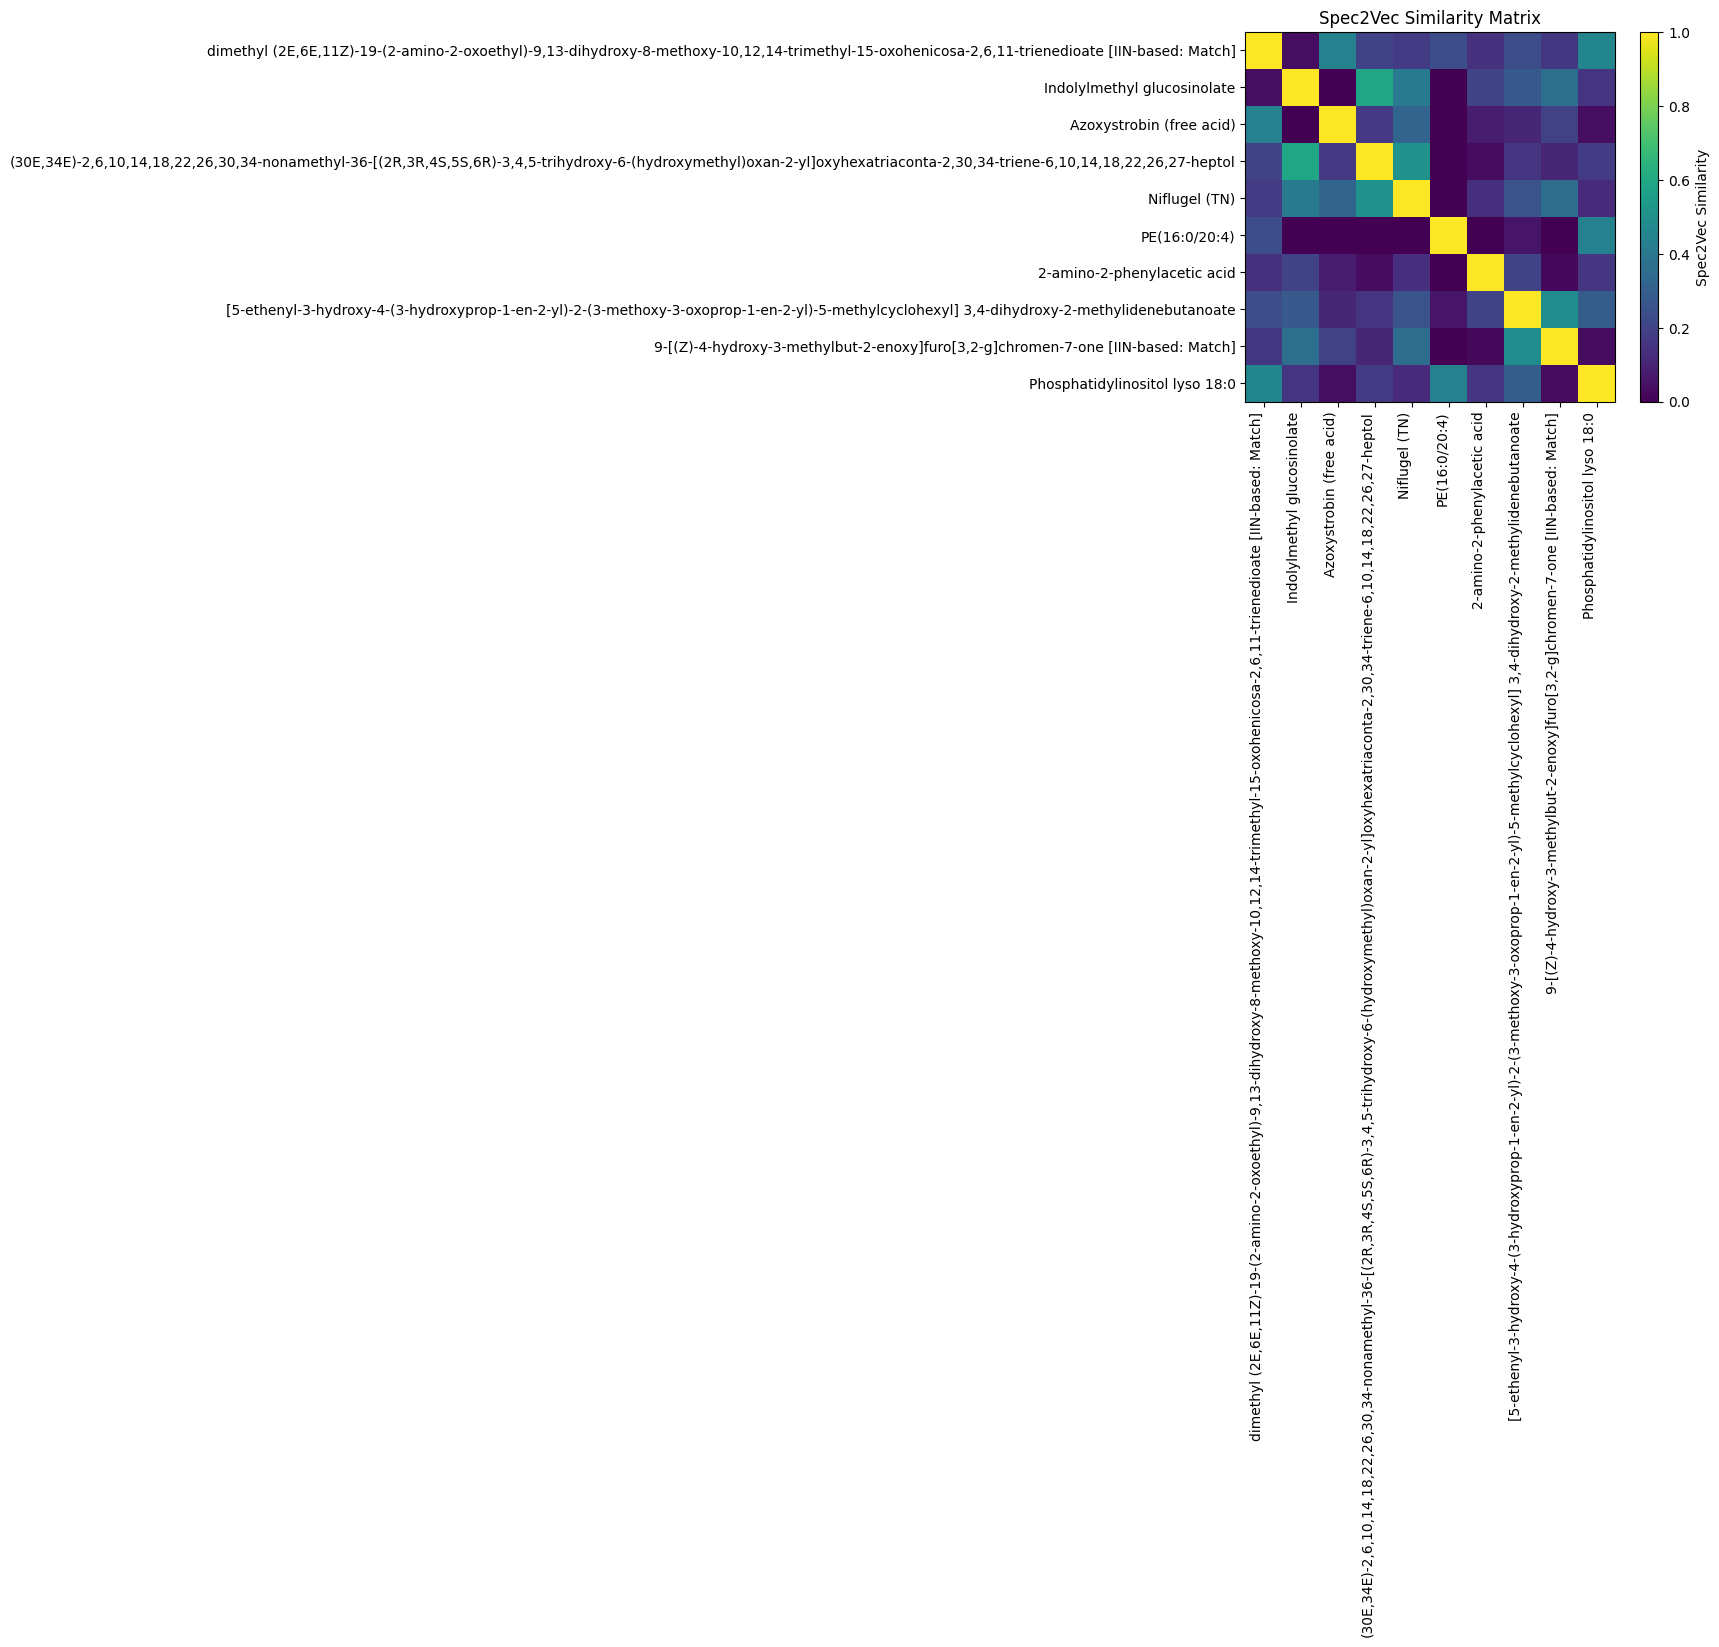

In [144]:
plt.imshow(S[:10, :10], cmap='viridis', vmin=0, vmax=1)
plt.title("Spec2Vec Similarity Matrix")
plt.xticks(ticks=np.arange(10), labels=[s.metadata.get('compound_name', 'Unknown') for s in valid_samples[:10]], rotation=90, ha='right')
plt.yticks(ticks=np.arange(10), labels=[s.metadata.get('compound_name', 'Unknown') for s in valid_samples[:10]])
plt.colorbar(label='Spec2Vec Similarity')
plt.show()

In [ ]:
# comparison with cosine

### Earth Mover Distance

### End